# Model Interpretation

This notebook investigates which market-microstructure features drive the
predictive models developed in the previous notebooks.

The analysis focuses primarily on the three asset-horizon pairs selected for
directional classification:

- TSLA — 500 ms
- AMZN — 500 ms
- BRK.B — 5 s

The main objectives are to:

1. identify the most influential features for each asset,
2. examine whether the direction of their effects is economically interpretable,
3. compare feature importance across assets, and
4. relate the classification results to the earlier return-regression results.

To preserve the experimental design, March 20 remains a held-out evaluation
period. Model interpretation is based on models fitted using the training
period rather than using the test set to select features or tune models.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

In [2]:
from pathlib import Path

DATA_DIR = Path("../data/processed")

ASSET_FILES = {
    "TSLA": "TSLA",
    "AMZN": "AMZN",
    "BRK.B": "BRK_B",
}

DATES = [
    "2026-03-16",
    "2026-03-17",
    "2026-03-18",
    "2026-03-19",
    "2026-03-20",
]

data = {}

for asset, file_asset in ASSET_FILES.items():
    frames = []

    for date in DATES:
        path = DATA_DIR / f"{file_asset}_{date}.parquet"
        df = pd.read_parquet(path).copy()
        df["date"] = date
        frames.append(df)

    data[asset] = pd.concat(frames, ignore_index=True)

    print(asset, data[asset].shape)

TSLA (234000, 75)
AMZN (234000, 75)
BRK.B (234000, 75)


In [3]:
SELECTED_TARGETS = {
    "TSLA": "target_500ms",
    "AMZN": "target_500ms",
    "BRK.B": "target_5s",
}

TAU = {
    "TSLA": 1.2559579505356809e-05,
    "AMZN": 2.340029718496282e-05,
    "BRK.B": 1.0220925300501525e-05,
}

TRAIN_DATES = ["2026-03-16", "2026-03-17", "2026-03-18"]
VAL_DATE = "2026-03-19"
TEST_DATE = "2026-03-20"

In [4]:
def make_classification_target(y, tau):
    return np.where(
        y < -tau, -1,
        np.where(y > tau, 1, 0)
    )

In [5]:
feature_cols = [
    "spread",
    "imbalance_l1",
    "imbalance_l5",
    "bid_depth_5",
    "ask_depth_5",
    "microprice_deviation",
    "event_count",
    "execution_count",
    "normalized_book_flow",
    "execution_imbalance",
    "return_500ms",
    "return_1s",
    "return_2s",
    "return_5s",
    "return_10s",
    "volatility_5s",
    "volatility_30s",
    "avg_events_5s",
    "avg_executions_5s",
]

print("Number of features:", len(feature_cols))

Number of features: 19


In [6]:
interpretation_data = {}

for asset in ["TSLA", "AMZN", "BRK.B"]:
    df = data[asset].copy()
    target_col = SELECTED_TARGETS[asset]

    df["classification_target"] = make_classification_target(
        df[target_col],
        TAU[asset]
    )

    train_df = df[df["date"].isin(TRAIN_DATES)].copy()

    mask = (
        train_df[feature_cols].notna().all(axis=1)
        & train_df[target_col].notna()
    )

    train_df = train_df.loc[mask].copy()

    X_train = train_df[feature_cols]
    y_train = train_df["classification_target"]

    interpretation_data[asset] = {
        "X_train": X_train,
        "y_train": y_train,
    }

    print(
        asset,
        "X:", X_train.shape,
        "y:", y_train.shape,
        "classes:", y_train.value_counts().sort_index().to_dict()
    )

TSLA X: (140217, 19) y: (140217,) classes: {-1: 47847, 0: 43699, 1: 48671}
AMZN X: (140217, 19) y: (140217,) classes: {-1: 39054, 0: 62534, 1: 38629}
BRK.B X: (140190, 19) y: (140190,) classes: {-1: 39052, 0: 66820, 1: 34318}


In [7]:
interpretation_models = {}

for asset in ["TSLA", "AMZN", "BRK.B"]:
    X_train = interpretation_data[asset]["X_train"]
    y_train = interpretation_data[asset]["y_train"]

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("classifier", LogisticRegression(
            class_weight="balanced",
            max_iter=1000
        ))
    ])

    model.fit(X_train, y_train)
    interpretation_models[asset] = model

    print(asset, "fitted")

TSLA fitted
AMZN fitted
BRK.B fitted


## Standardized Logistic Regression Coefficients

Because each model is fitted after standardizing the input features, the
coefficient magnitudes are comparable within each asset.

For the three-class Logistic Regression model, each feature has a separate
coefficient for DOWN, STATIONARY, and UP. A positive coefficient indicates
that increasing the corresponding standardized feature increases the model's
score for that class, holding the other features fixed.

Coefficient magnitude is used as a measure of model influence, while the sign
indicates the direction of the association with each class.

In [8]:
class_names = {
    -1: "DOWN",
     0: "STATIONARY",
     1: "UP",
}

coefficient_tables = {}

for asset, model in interpretation_models.items():

    logistic = model.named_steps["classifier"]

    coef_df = pd.DataFrame(
        logistic.coef_.T,
        index=feature_cols,
        columns=[class_names[c] for c in logistic.classes_]
    )

    coef_df["max_abs_coefficient"] = (
        coef_df[["DOWN", "STATIONARY", "UP"]]
        .abs()
        .max(axis=1)
    )

    coef_df = coef_df.sort_values(
        "max_abs_coefficient",
        ascending=False
    )

    coefficient_tables[asset] = coef_df

    print("=" * 80)
    print(asset)
    print("=" * 80)

    display(coef_df.head(15))

TSLA


,DOWN,STATIONARY,UP,max_abs_coefficient
volatility_30s,0.066638,-0.136671,0.070033,0.136671
event_count,0.051023,-0.097476,0.046453,0.097476
imbalance_l1,-0.086816,0.015435,0.071381,0.086816
avg_events_5s,0.037533,-0.081031,0.043498,0.081031
volatility_5s,0.021508,-0.051940,0.030432,0.051940
return_500ms,0.028002,0.001079,-0.029081,0.029081
spread,-0.016420,0.027722,-0.011302,0.027722
return_10s,0.007728,0.018908,-0.026636,0.026636
normalized_book_flow,-0.023940,0.006724,0.017216,0.023940
return_1s,0.022041,-0.000009,-0.022031,0.022041


AMZN


,DOWN,STATIONARY,UP,max_abs_coefficient
avg_events_5s,0.100491,-0.200187,0.099696,0.200187
imbalance_l1,-0.156970,0.018189,0.138781,0.156970
event_count,0.037516,-0.092112,0.054596,0.092112
ask_depth_5,0.020811,-0.087601,0.066790,0.087601
avg_executions_5s,-0.043953,0.083958,-0.040005,0.083958
bid_depth_5,0.052099,-0.078693,0.026594,0.078693
volatility_30s,0.039364,-0.070911,0.031547,0.070911
imbalance_l5,-0.024642,-0.042227,0.066869,0.066869
return_500ms,0.043377,0.013683,-0.057061,0.057061
spread,0.015727,-0.052353,0.036627,0.052353


BRK.B


,DOWN,STATIONARY,UP,max_abs_coefficient
volatility_30s,0.080659,-0.194701,0.114042,0.194701
avg_events_5s,0.109476,-0.159604,0.050128,0.159604
imbalance_l1,-0.120651,-0.007226,0.127878,0.127878
event_count,0.042281,-0.091411,0.049130,0.091411
microprice_deviation,0.087573,-0.003013,-0.084559,0.087573
spread,-0.044693,0.059200,-0.014507,0.059200
return_5s,0.054845,-0.018743,-0.036102,0.054845
execution_imbalance,-0.053391,0.005081,0.048309,0.053391
return_500ms,0.050753,-0.001247,-0.049505,0.050753
volatility_5s,0.045670,-0.042117,-0.003553,0.045670


In [9]:
directional_tables = {}

for asset, coef_df in coefficient_tables.items():

    directional_df = coef_df[
        ["DOWN", "STATIONARY", "UP"]
    ].copy()

    directional_df["UP_minus_DOWN"] = (
        directional_df["UP"] - directional_df["DOWN"]
    )

    directional_df["abs_directional_contrast"] = (
        directional_df["UP_minus_DOWN"].abs()
    )

    directional_df = directional_df.sort_values(
        "abs_directional_contrast",
        ascending=False
    )

    directional_tables[asset] = directional_df

    print("=" * 80)
    print(asset, "— strongest UP vs DOWN contrasts")
    print("=" * 80)

    display(directional_df.head(10))

TSLA — strongest UP vs DOWN contrasts


,DOWN,STATIONARY,UP,UP_minus_DOWN,abs_directional_contrast
imbalance_l1,-0.086816,0.015435,0.071381,0.158198,0.158198
return_500ms,0.028002,0.001079,-0.029081,-0.057084,0.057084
return_1s,0.022041,-0.000009,-0.022031,-0.044072,0.044072
normalized_book_flow,-0.023940,0.006724,0.017216,0.041155,0.041155
return_10s,0.007728,0.018908,-0.026636,-0.034365,0.034365
microprice_deviation,-0.016135,-0.000279,0.016414,0.032549,0.032549
imbalance_l5,-0.002441,-0.012228,0.014669,0.017111,0.017111
return_5s,0.010570,-0.010785,0.000215,-0.010355,0.010355
execution_imbalance,0.010710,-0.012224,0.001514,-0.009196,0.009196
volatility_5s,0.021508,-0.051940,0.030432,0.008924,0.008924


AMZN — strongest UP vs DOWN contrasts


,DOWN,STATIONARY,UP,UP_minus_DOWN,abs_directional_contrast
imbalance_l1,-0.156970,0.018189,0.138781,0.295751,0.295751
return_500ms,0.043377,0.013683,-0.057061,-0.100438,0.100438
imbalance_l5,-0.024642,-0.042227,0.066869,0.091511,0.091511
ask_depth_5,0.020811,-0.087601,0.066790,0.045979,0.045979
bid_depth_5,0.052099,-0.078693,0.026594,-0.025505,0.025505
execution_imbalance,0.000121,-0.021151,0.021029,0.020908,0.020908
spread,0.015727,-0.052353,0.036627,0.020900,0.020900
microprice_deviation,0.003112,0.012325,-0.015438,-0.018550,0.018550
return_10s,0.004710,0.008827,-0.013537,-0.018247,0.018247
event_count,0.037516,-0.092112,0.054596,0.017081,0.017081


BRK.B — strongest UP vs DOWN contrasts


,DOWN,STATIONARY,UP,UP_minus_DOWN,abs_directional_contrast
imbalance_l1,-0.120651,-0.007226,0.127878,0.248529,0.248529
microprice_deviation,0.087573,-0.003013,-0.084559,-0.172132,0.172132
execution_imbalance,-0.053391,0.005081,0.048309,0.101700,0.101700
return_500ms,0.050753,-0.001247,-0.049505,-0.100258,0.100258
return_5s,0.054845,-0.018743,-0.036102,-0.090947,0.090947
return_2s,0.033981,-0.006796,-0.027185,-0.061166,0.061166
avg_events_5s,0.109476,-0.159604,0.050128,-0.059348,0.059348
volatility_5s,0.045670,-0.042117,-0.003553,-0.049223,0.049223
return_1s,0.021490,-0.001266,-0.020224,-0.041714,0.041714
ask_depth_5,-0.035899,0.035118,0.000782,0.036681,0.036681


## Directional Feature Effects

The UP-minus-DOWN coefficient contrast provides a compact measure of how each
feature affects the model's directional preference.

A positive contrast means that higher values of the feature shift the model
toward UP relative to DOWN, while a negative contrast shifts the model toward
DOWN relative to UP.

This distinction is useful because some features may be important primarily
for distinguishing price movement from stationarity rather than for
determining the direction of the movement.

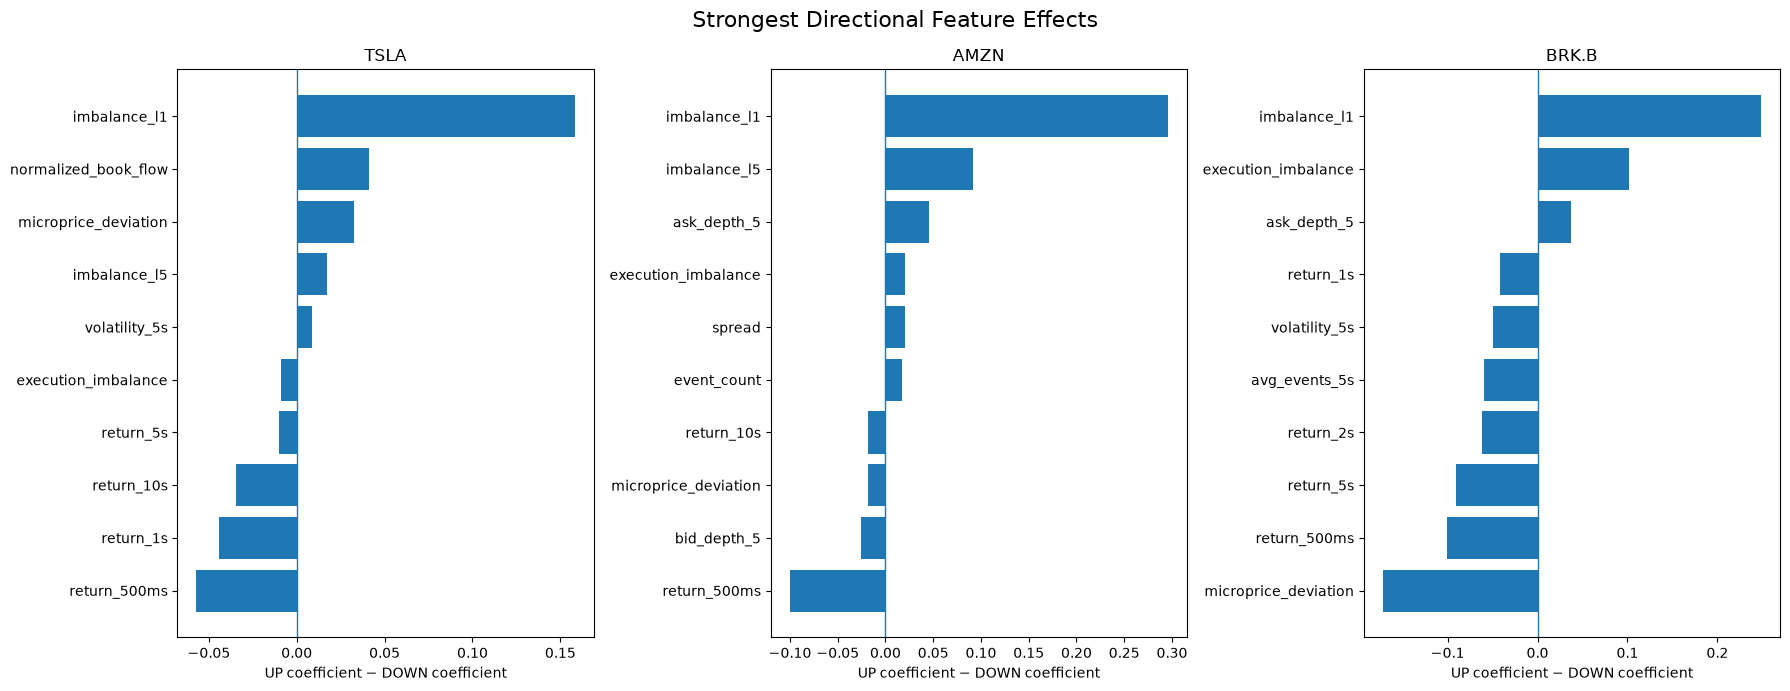

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 7))

for ax, asset in zip(axes, ["TSLA", "AMZN", "BRK.B"]):

    plot_df = (
        directional_tables[asset]
        .head(10)
        .sort_values("UP_minus_DOWN")
    )

    ax.barh(
        plot_df.index,
        plot_df["UP_minus_DOWN"]
    )

    ax.axvline(0, linewidth=1)

    ax.set_title(asset)
    ax.set_xlabel("UP coefficient − DOWN coefficient")

fig.suptitle(
    "Strongest Directional Feature Effects",
    fontsize=16
)

plt.tight_layout()
plt.show()

In [11]:
directional_comparison = pd.DataFrame({
    asset: directional_tables[asset]["UP_minus_DOWN"]
    for asset in ["TSLA", "AMZN", "BRK.B"]
})

directional_comparison["mean_contrast"] = (
    directional_comparison[["TSLA", "AMZN", "BRK.B"]].mean(axis=1)
)

directional_comparison["mean_abs_contrast"] = (
    directional_comparison[["TSLA", "AMZN", "BRK.B"]]
    .abs()
    .mean(axis=1)
)

directional_comparison["same_sign_all_assets"] = (
    (
        directional_comparison[["TSLA", "AMZN", "BRK.B"]] > 0
    ).all(axis=1)
    |
    (
        directional_comparison[["TSLA", "AMZN", "BRK.B"]] < 0
    ).all(axis=1)
)

display(
    directional_comparison
    .sort_values("mean_abs_contrast", ascending=False)
    .head(15)
)

,TSLA,AMZN,BRK.B,mean_contrast,mean_abs_contrast,same_sign_all_assets
imbalance_l1,0.158198,0.295751,0.248529,0.234159,0.234159,True
return_500ms,-0.057084,-0.100438,-0.100258,-0.085927,0.085927,True
microprice_deviation,0.032549,-0.018550,-0.172132,-0.052711,0.074410,False
imbalance_l5,0.017111,0.091511,0.029613,0.046078,0.046078,True
execution_imbalance,-0.009196,0.020908,0.101700,0.037804,0.043935,False
return_5s,-0.010355,-0.005194,-0.090947,-0.035499,0.035499,True
return_1s,-0.044072,-0.015905,-0.041714,-0.033897,0.033897,True
ask_depth_5,-0.000165,0.045979,0.036681,0.027498,0.027608,False
return_10s,-0.034365,-0.018247,0.023937,-0.009559,0.025516,False
return_2s,0.005465,0.007481,-0.061166,-0.016073,0.024704,False


### Cross-asset interpretation

The coefficient analysis reveals several directional patterns that are
consistent across assets. Level-1 order-book imbalance is the strongest
cross-asset directional signal: its UP-minus-DOWN coefficient is positive
for TSLA, AMZN, and BRK.B, indicating that greater bid-side imbalance shifts
the classifier toward an UP prediction relative to DOWN.

Recent returns show the opposite pattern. The 500 ms return has a negative
UP-minus-DOWN coefficient for all three assets, with the same sign also
observed for the 1 s and 5 s returns. Within the fitted models, this is
consistent with a short-horizon reversal-type relationship rather than
simple return continuation.

Other features are less stable across assets. In particular,
microprice deviation has substantially different directional effects across
TSLA, AMZN, and BRK.B. Thus, although some microstructure relationships
generalize across the three securities, a substantial part of the predictive
structure remains asset-specific.

These coefficients describe associations within the fitted multivariate
classification models and should not be interpreted as causal effects.

## Movement Versus Stationarity

The UP-minus-DOWN contrast isolates directional information, but some features
may instead indicate whether the price is likely to move at all.

To examine this distinction, we compare the average directional coefficient

$$
\frac{\beta_{\text{UP}}+\beta_{\text{DOWN}}}{2}
$$

with the STATIONARY coefficient.

A positive movement contrast indicates that higher values of the feature shift
the model toward a directional move (UP or DOWN) rather than STATIONARY.

In [12]:
movement_tables = {}

for asset, coef_df in coefficient_tables.items():

    movement_df = coef_df[
        ["DOWN", "STATIONARY", "UP"]
    ].copy()

    movement_df["MOVING"] = (
        movement_df["DOWN"] + movement_df["UP"]
    ) / 2

    movement_df["MOVING_minus_STATIONARY"] = (
        movement_df["MOVING"]
        - movement_df["STATIONARY"]
    )

    movement_df["abs_movement_contrast"] = (
        movement_df["MOVING_minus_STATIONARY"].abs()
    )

    movement_df = movement_df.sort_values(
        "abs_movement_contrast",
        ascending=False
    )

    movement_tables[asset] = movement_df

    print("=" * 80)
    print(asset, "— strongest MOVING vs STATIONARY contrasts")
    print("=" * 80)

    display(
        movement_df[
            [
                "DOWN",
                "STATIONARY",
                "UP",
                "MOVING_minus_STATIONARY",
                "abs_movement_contrast"
            ]
        ].head(10)
    )

TSLA — strongest MOVING vs STATIONARY contrasts


,DOWN,STATIONARY,UP,MOVING_minus_STATIONARY,abs_movement_contrast
volatility_30s,0.066638,-0.136671,0.070033,0.205006,0.205006
event_count,0.051023,-0.097476,0.046453,0.146214,0.146214
avg_events_5s,0.037533,-0.081031,0.043498,0.121546,0.121546
volatility_5s,0.021508,-0.051940,0.030432,0.077910,0.077910
spread,-0.016420,0.027722,-0.011302,-0.041582,0.041582
execution_count,-0.011099,0.021578,-0.010479,-0.032367,0.032367
return_10s,0.007728,0.018908,-0.026636,-0.028362,0.028362
imbalance_l1,-0.086816,0.015435,0.071381,-0.023153,0.023153
ask_depth_5,-0.007223,0.014610,-0.007388,-0.021915,0.021915
imbalance_l5,-0.002441,-0.012228,0.014669,0.018342,0.018342


AMZN — strongest MOVING vs STATIONARY contrasts


,DOWN,STATIONARY,UP,MOVING_minus_STATIONARY,abs_movement_contrast
avg_events_5s,0.100491,-0.200187,0.099696,0.300280,0.300280
event_count,0.037516,-0.092112,0.054596,0.138168,0.138168
ask_depth_5,0.020811,-0.087601,0.066790,0.131402,0.131402
avg_executions_5s,-0.043953,0.083958,-0.040005,-0.125937,0.125937
bid_depth_5,0.052099,-0.078693,0.026594,0.118039,0.118039
volatility_30s,0.039364,-0.070911,0.031547,0.106366,0.106366
spread,0.015727,-0.052353,0.036627,0.078530,0.078530
volatility_5s,0.026624,-0.043781,0.017157,0.065672,0.065672
imbalance_l5,-0.024642,-0.042227,0.066869,0.063341,0.063341
execution_imbalance,0.000121,-0.021151,0.021029,0.031726,0.031726


BRK.B — strongest MOVING vs STATIONARY contrasts


,DOWN,STATIONARY,UP,MOVING_minus_STATIONARY,abs_movement_contrast
volatility_30s,0.080659,-0.194701,0.114042,0.292052,0.292052
avg_events_5s,0.109476,-0.159604,0.050128,0.239406,0.239406
event_count,0.042281,-0.091411,0.049130,0.137116,0.137116
spread,-0.044693,0.059200,-0.014507,-0.088800,0.088800
volatility_5s,0.045670,-0.042117,-0.003553,0.063175,0.063175
ask_depth_5,-0.035899,0.035118,0.000782,-0.052677,0.052677
bid_depth_5,-0.005270,0.019962,-0.014692,-0.029943,0.029943
return_10s,-0.021645,0.019353,0.002292,-0.029030,0.029030
return_5s,0.054845,-0.018743,-0.036102,0.028114,0.028114
avg_executions_5s,-0.009148,-0.017499,0.026646,0.026248,0.026248


### Movement-versus-stationarity interpretation

The movement contrasts reveal a different structure from the directional
UP-versus-DOWN analysis. Recent market activity and volatility are the
strongest and most consistent features for distinguishing a price movement
from a stationary outcome.

Recent event intensity (`avg_events_5s`) has the largest average movement
contrast and is positive for all three assets. The 30-second volatility
measure is similarly strong and consistently positive across TSLA, AMZN,
and BRK.B. Contemporaneous `event_count` and 5-second volatility also have
positive movement contrasts for all three assets.

These patterns indicate that periods of elevated recent activity and
volatility shift the classifier away from the STATIONARY class and toward
a directional price movement.

Other features are less stable across securities. Spread and level-5 depth,
for example, exhibit different signs across the three assets, suggesting
that some aspects of the movement-versus-stationarity relationship remain
asset-specific.

Together with the UP-versus-DOWN analysis, the results suggest a useful
separation between two types of information: order-book imbalance primarily
contains information about the direction of a potential move, whereas
volatility and market-activity variables contain information about whether
a move is likely to occur at all.

In [13]:
movement_contrast_comparison = pd.DataFrame({
    asset: movement_tables[asset]["MOVING_minus_STATIONARY"]
    for asset in ["TSLA", "AMZN", "BRK.B"]
})

movement_contrast_comparison["mean_contrast"] = (
    movement_contrast_comparison[["TSLA", "AMZN", "BRK.B"]].mean(axis=1)
)

movement_contrast_comparison["mean_abs_contrast"] = (
    movement_contrast_comparison[["TSLA", "AMZN", "BRK.B"]]
    .abs()
    .mean(axis=1)
)

movement_contrast_comparison["same_sign_all_assets"] = (
    (
        movement_contrast_comparison[["TSLA", "AMZN", "BRK.B"]] > 0
    ).all(axis=1)
    |
    (
        movement_contrast_comparison[["TSLA", "AMZN", "BRK.B"]] < 0
    ).all(axis=1)
)

movement_contrast_comparison = (
    movement_contrast_comparison
    .sort_values("mean_abs_contrast", ascending=False)
)

display(movement_contrast_comparison.head(15))

,TSLA,AMZN,BRK.B,mean_contrast,mean_abs_contrast,same_sign_all_assets
avg_events_5s,0.121546,0.300280,0.239406,0.220411,0.220411,True
volatility_30s,0.205006,0.106366,0.292052,0.201141,0.201141,True
event_count,0.146214,0.138168,0.137116,0.140499,0.140499,True
spread,-0.041582,0.078530,-0.088800,-0.017284,0.069637,False
volatility_5s,0.077910,0.065672,0.063175,0.068919,0.068919,True
ask_depth_5,-0.021915,0.131402,-0.052677,0.018937,0.068665,False
bid_depth_5,-0.012688,0.118039,-0.029943,0.025136,0.053557,False
avg_executions_5s,0.003312,-0.125937,0.026248,-0.032125,0.051832,False
imbalance_l5,0.018342,0.063341,0.018289,0.033324,0.033324,True
return_10s,-0.028362,-0.013240,-0.029030,-0.023544,0.023544,True


## Final Interpretation

The coefficient analysis suggests that the predictive information contained
in the microstructure features can be separated into two broad components:
directional information and movement information.

For direction, level-1 order-book imbalance provides the clearest and most
consistent signal. Its UP-minus-DOWN coefficient is positive for TSLA, AMZN,
and BRK.B and is substantially larger than most other directional contrasts.
Deeper order-book imbalance also shows a consistent positive relationship,
although the effect is weaker. In contrast, recent short-horizon returns,
particularly the 500 ms return, have negative directional contrasts across
all three assets, indicating a short-horizon reversal-type relationship
within the fitted models.

A different set of features is important for distinguishing MOVING from
STATIONARY outcomes. Recent event intensity (`avg_events_5s`), 30-second
volatility, and contemporaneous event count have strong positive movement
contrasts across all three assets. Five-second volatility is also consistently
positive. These results suggest that periods of elevated market activity and
volatility increase the model's tendency to predict a price movement rather
than a stationary outcome.

Not all relationships generalize across securities. Features such as
microprice deviation, spread, execution imbalance, and book depth exhibit
asset-dependent effects. Thus, the results support the existence of some
common microstructure patterns while also indicating substantial cross-asset
heterogeneity.

Overall, the interpretation is consistent with the modest predictive
performance observed in the modeling experiments. The features contain
detectable structure, but the signal is weak rather than universally strong.
Order-book imbalance appears most informative about the direction of a
potential move, whereas volatility and market-activity variables are more
informative about whether a move occurs at all. These coefficients represent
conditional associations within the fitted multivariate models and should
not be interpreted as causal effects.